# RBIG as an Invertible Neural Network Flow (INNF Demo)

This notebook demonstrates RBIG as an example of an **Invertible Neural
Network Flow** (INNF) — a generative model based on composable invertible
transformations.

We show the RBIG algorithm step by step on a 2-D sin-wave dataset using the
new composable API:

- `RBIGLayer` — a single invertible layer (marginal Gaussianization + PCA)
- `AnnealedRBIG` — the full iterative model

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from rbig import AnnealedRBIG, MarginalGaussianize, PCARotation, RBIGLayer

sns.set_style("whitegrid")

/home/azureuser/localfiles/rbig/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data

2-D sin-wave dataset (same as the original `innf_demo.ipynb`).

> The original notebook used `make_toy_data("rbig_sin_wave", ...)` from the
> `destructive-deep-learning` package.  We generate the data directly here.

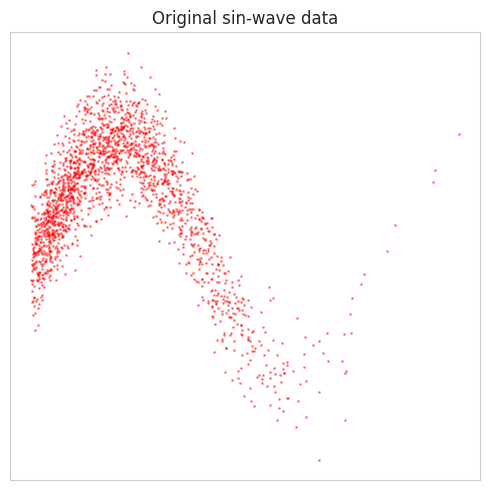

In [2]:
seed = 123
rng = np.random.RandomState(seed=seed)
n_samples = 2_000

x = np.abs(2 * rng.randn(1, n_samples))
y = np.sin(x) + 0.25 * rng.randn(1, n_samples)
X = np.vstack((x, y)).T

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X[:, 0], X[:, 1], s=1, c="red", alpha=0.4)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Original sin-wave data")
plt.tight_layout()
plt.show()

## RBIG Algorithm — Step by Step (1 Layer)

A single RBIG layer has two sub-steps:

1. **Marginal Gaussianization** — map each feature to N(0, 1) using its
   empirical CDF and the probit function.
2. **Rotation (PCA)** — decorrelate the Gaussianized features via a whitening
   PCA rotation.

In [3]:
# Build and fit a single layer
layer1 = RBIGLayer(
    marginal=MarginalGaussianize(),
    rotation=PCARotation(whiten=True),
)
layer1.fit(X)

RBIGLayer(marginal=MarginalGaussianize(), rotation=PCARotation())

### Step I — After Marginal Gaussianization

We can inspect the intermediate state by applying only the marginal transform.

<Figure size 500x500 with 0 Axes>

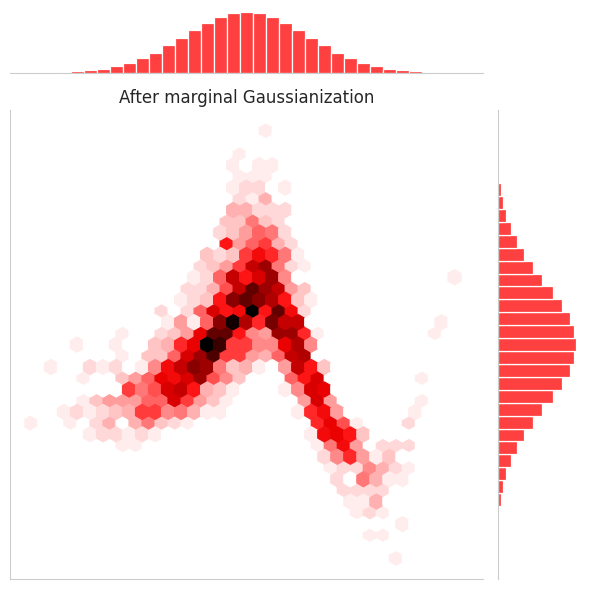

In [4]:
X_mg = layer1.marginal.transform(X)

fig = plt.figure(figsize=(5, 5))
g = sns.jointplot(x=X_mg[:, 0], y=X_mg[:, 1], kind="hex", color="red")
g.ax_joint.set_xticks([])
g.ax_joint.set_yticks([])
g.ax_joint.set_title("After marginal Gaussianization")
plt.tight_layout()
plt.show()

### Step II — After Rotation (1 full RBIG layer)

<Figure size 500x500 with 0 Axes>

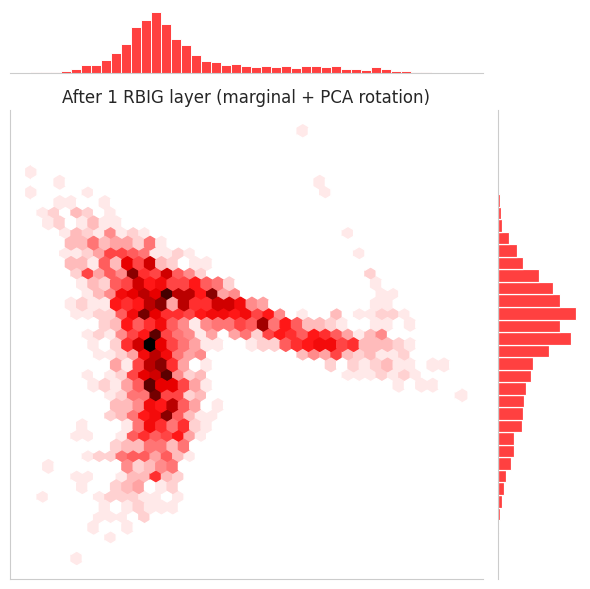

In [5]:
X_layer1 = layer1.transform(X)

fig = plt.figure(figsize=(5, 5))
g = sns.jointplot(x=X_layer1[:, 0], y=X_layer1[:, 1], kind="hex", color="red")
g.ax_joint.set_xticks([])
g.ax_joint.set_yticks([])
g.ax_joint.set_title("After 1 RBIG layer (marginal + PCA rotation)")
plt.tight_layout()
plt.show()

## RBIG Algorithm — Multiple Layers

We show the output after 1, 2, 3, 4, 5, and 6 layers.

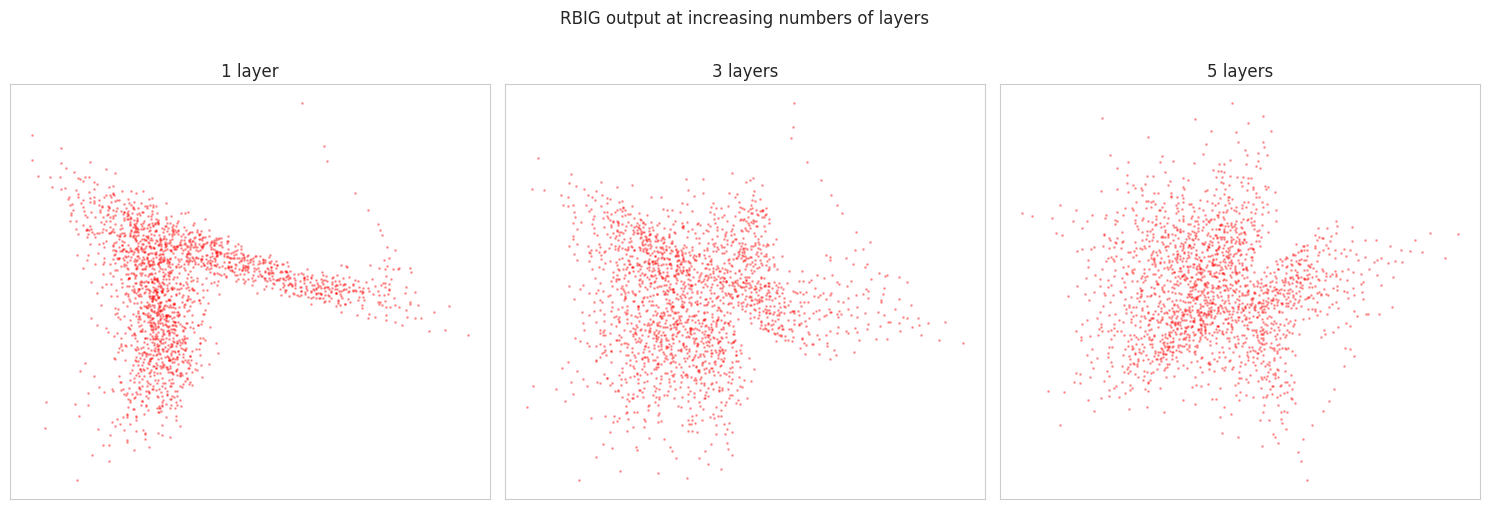

In [6]:
n_layer_list = [1, 3, 5]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, n in zip(axes, n_layer_list, strict=False):
    model = AnnealedRBIG(
        n_layers=n,
        rotation="pca",
        patience=n + 1,  # never stop early in this demo
        random_state=seed,
    )
    Z = model.fit_transform(X)
    ax.scatter(Z[:, 0], Z[:, 1], s=1, alpha=0.3, color="red")
    ax.set_title(f"{n} layer{'s' if n > 1 else ''}")
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("RBIG output at increasing numbers of layers", y=1.01)
plt.tight_layout()
plt.show()

## Full RBIG Algorithm (Converged)

We now run `AnnealedRBIG` until the total correlation converges.

Converged after 27 layers


<Figure size 500x500 with 0 Axes>

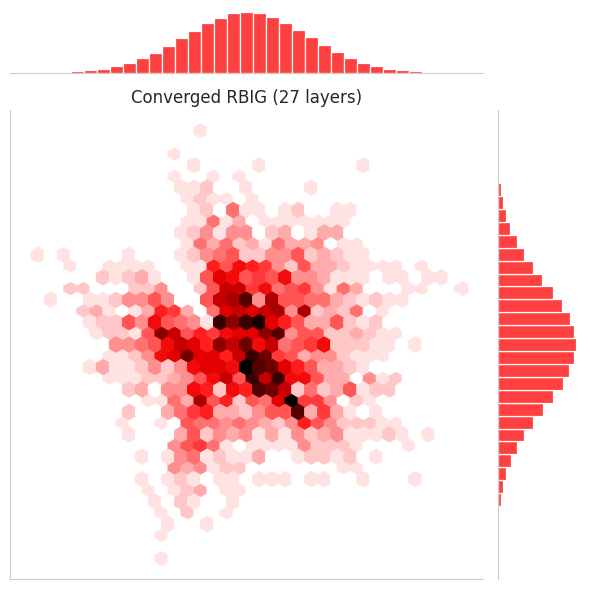

In [7]:
rbig_full = AnnealedRBIG(
    n_layers=50,
    rotation="pca",
    patience=10,
    random_state=seed,
)
rbig_full.fit(X)
Z_full = rbig_full.transform(X)

print(f"Converged after {len(rbig_full.layers_)} layers")

fig = plt.figure(figsize=(5, 5))
g = sns.jointplot(x=Z_full[:, 0], y=Z_full[:, 1], kind="hex", color="red")
g.ax_joint.set_xticks([])
g.ax_joint.set_yticks([])
g.ax_joint.set_title(f"Converged RBIG ({len(rbig_full.layers_)} layers)")
plt.tight_layout()
plt.show()

## Properties of the Learned Flow

### Invertibility

RBIG is an exact invertible transform.

In [8]:
X_reconstructed = rbig_full.inverse_transform(Z_full)
residual = np.abs(X - X_reconstructed).mean()
print(f"Mean absolute reconstruction error: {residual:.4e}")

Mean absolute reconstruction error: 2.5275e-02


### TC Convergence Curve

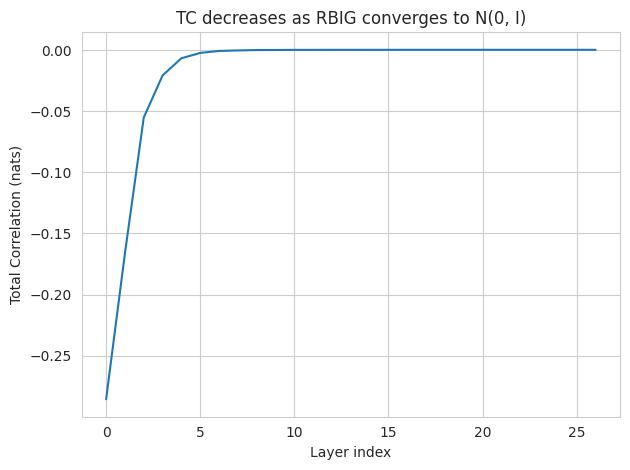

In [9]:
fig, ax = plt.subplots()
ax.plot(rbig_full.tc_per_layer_)
ax.set_xlabel("Layer index")
ax.set_ylabel("Total Correlation (nats)")
ax.set_title("TC decreases as RBIG converges to N(0, I)")
plt.tight_layout()
plt.show()

### Log-Likelihood (Density Estimation)

RBIG implements the change-of-variables formula for density estimation:

$$\log p(x) = \log p_Z(f(x)) + \log|\det J_f(x)|$$

Log-likelihood  — mean: 21.637, min: -8.082, max: 117.894


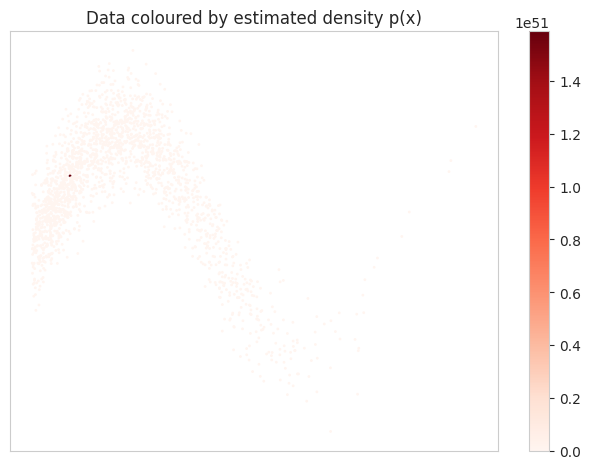

In [10]:
log_probs = rbig_full.score_samples(X)
print(
    f"Log-likelihood  — mean: {log_probs.mean():.3f}, "
    f"min: {log_probs.min():.3f}, max: {log_probs.max():.3f}"
)

fig, ax = plt.subplots()
h = ax.scatter(X[:, 0], X[:, 1], s=1, c=np.exp(log_probs), cmap="Reds")
ax.set_title("Data coloured by estimated density p(x)")
ax.set_xticks([])
ax.set_yticks([])
plt.colorbar(h, ax=ax)
plt.tight_layout()
plt.show()

### Generative Sampling

Because RBIG is invertible we can synthesize new samples by mapping standard
Gaussian noise through the inverse transform.

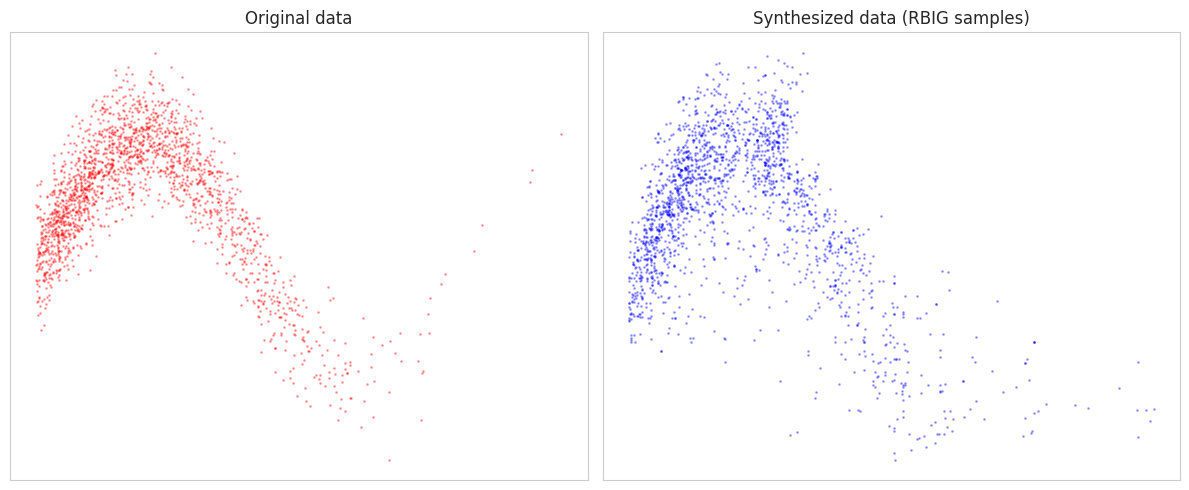

In [11]:
X_synth = rbig_full.sample(n_samples=n_samples, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X[:, 0], X[:, 1], s=1, alpha=0.3, c="red")
axes[0].set_title("Original data")
axes[0].set_xticks([])
axes[0].set_yticks([])

axes[1].scatter(X_synth[:, 0], X_synth[:, 1], s=1, alpha=0.3, c="blue")
axes[1].set_title("Synthesized data (RBIG samples)")
axes[1].set_xticks([])
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

## Summary

RBIG implements a simple, composable normalizing flow:

| Property | RBIG |
|---|---|
| Invertible | ✓ (exact) |
| Density estimation | ✓ (`score_samples`) |
| Generative sampling | ✓ (`sample`) or `inverse_transform` |
| Convergence criterion | TC convergence |
| Building block | `RBIGLayer` = `MarginalGaussianize` + `PCARotation` |